In [48]:
# From Fear to Flight

###Safety, affordability, and tourism patterns for first-time solo travel.

In [49]:
## Note
###Cost of Living Index is a relative affordability measure, not exact daily travel cost in USD.

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [51]:
quality_df = pd.read_csv("quality_of_life_indices_by_country.csv")
tourism_df = pd.read_csv("world_tourism_economy_data.csv")

In [52]:
print("Quality of life shape:", quality_df.shape)
print("Tourism shape:", tourism_df.shape)

Quality of life shape: (1495, 12)
Tourism shape: (6650, 11)


In [53]:
quality_df.head()

,Rank,Country,Quality of Life Index,Purchasing Power Index,Safety Index,Health Care Index,Cost of Living Index,Property Price to Income Ratio,Traffic Commute Time Index,Pollution Index,Climate Index,Year
0,1,Switzerland,222.9,146.5,73.2,66.3,126.0,7.3,25.6,24.1,-,2015
1,2,Germany,195.9,111.8,71.5,75.6,76.3,6.6,31.1,28.3,-,2015
2,3,Sweden,193.9,110.9,57.9,76.3,82.9,9.2,26.9,15.1,-,2015
3,4,United States,192.5,126.1,50.0,67.8,76.5,2.6,36.0,31.4,-,2015
4,5,Finland,190.2,101.2,70.5,69.4,89.7,7.0,33.2,14.9,-,2015


In [54]:
tourism_df.head()

,country,country_code,year,tourism_receipts,tourism_arrivals,tourism_exports,tourism_departures,tourism_expenditures,gdp,inflation,unemployment
0,Aruba,ABW,1999,7.820000e+08,9.720000e+05,62.542949,NaN,9.495387,1.722905e+09,2.280372,NaN
1,Africa Eastern and Southern,AFE,1999,8.034209e+09,1.530938e+07,12.204030,NaN,7.760536,2.654293e+11,7.819865,NaN
2,Afghanistan,AFG,1999,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Africa Western and Central,AFW,1999,1.443613e+09,3.897975e+06,3.974476,NaN,6.147291,1.394683e+11,0.372266,NaN
4,Angola,AGO,1999,3.100000e+07,4.500000e+04,0.583858,NaN,2.489638,6.152923e+09,248.195902,NaN


In [55]:
print("Quality columns:")
print(quality_df.columns.tolist())

print("\nTourism columns:")
print(tourism_df.columns.tolist())

Quality columns:
['Rank', 'Country', 'Quality of Life Index', 'Purchasing Power Index', 'Safety Index', 'Health Care Index', 'Cost of Living Index', 'Property Price to Income Ratio', 'Traffic Commute Time Index', 'Pollution Index', 'Climate Index', 'Year']

Tourism columns:
['country', 'country_code', 'year', 'tourism_receipts', 'tourism_arrivals', 'tourism_exports', 'tourism_departures', 'tourism_expenditures', 'gdp', 'inflation', 'unemployment']


In [56]:
quality_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1495 entries, 0 to 1494
Data columns (total 12 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Rank                            1495 non-null   int64  
 1   Country                         1495 non-null   object 
 2   Quality of Life Index           1495 non-null   float64
 3   Purchasing Power Index          1495 non-null   float64
 4   Safety Index                    1495 non-null   float64
 5   Health Care Index               1495 non-null   float64
 6   Cost of Living Index            1495 non-null   float64
 7   Property Price to Income Ratio  1495 non-null   float64
 8   Traffic Commute Time Index      1495 non-null   float64
 9   Pollution Index                 1495 non-null   float64
 10  Climate Index                   1495 non-null   object 
 11  Year                            1495 non-null   object 
dtypes: float64(8), int64(1), object(3)

In [57]:
tourism_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6650 entries, 0 to 6649
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   country               6650 non-null   object 
 1   country_code          6650 non-null   object 
 2   year                  6650 non-null   int64  
 3   tourism_receipts      4289 non-null   float64
 4   tourism_arrivals      4949 non-null   float64
 5   tourism_exports       4114 non-null   float64
 6   tourism_departures    2589 non-null   float64
 7   tourism_expenditures  4173 non-null   float64
 8   gdp                   6424 non-null   float64
 9   inflation             5668 non-null   float64
 10  unemployment          3658 non-null   float64
dtypes: float64(8), int64(1), object(2)
memory usage: 571.6+ KB


In [58]:
quality_df.isna().sum().sort_values(ascending=False).head(15)

Rank                              0
Country                           0
Quality of Life Index             0
Purchasing Power Index            0
Safety Index                      0
Health Care Index                 0
Cost of Living Index              0
Property Price to Income Ratio    0
Traffic Commute Time Index        0
Pollution Index                   0
Climate Index                     0
Year                              0
dtype: int64

In [59]:
tourism_df.isna().sum().sort_values(ascending=False).head(15)

tourism_departures      4061
unemployment            2992
tourism_exports         2536
tourism_expenditures    2477
tourism_receipts        2361
tourism_arrivals        1701
inflation                982
gdp                      226
country                    0
country_code               0
year                       0
dtype: int64

In [60]:
## Next
###Clean columns, keep only relevant variables, and prepare both datasets for merging.

In [61]:
quality_df.columns.tolist()

['Rank',
 'Country',
 'Quality of Life Index',
 'Purchasing Power Index',
 'Safety Index',
 'Health Care Index',
 'Cost of Living Index',
 'Property Price to Income Ratio',
 'Traffic Commute Time Index',
 'Pollution Index',
 'Climate Index',
 'Year']

In [62]:
tourism_df.columns.tolist()

['country',
 'country_code',
 'year',
 'tourism_receipts',
 'tourism_arrivals',
 'tourism_exports',
 'tourism_departures',
 'tourism_expenditures',
 'gdp',
 'inflation',
 'unemployment']

In [63]:
### keep only relevant columns from quality dataset
quality_clean = quality_df[["Country", "Safety Index", "Cost of Living Index"]].copy()

### rename columns
quality_clean = quality_clean.rename(columns={
    "Country": "country",
    "Safety Index": "safety_index",
    "Cost of Living Index": "cost_of_living_index"
})

quality_clean.head()

,country,safety_index,cost_of_living_index
0,Switzerland,73.2,126.0
1,Germany,71.5,76.3
2,Sweden,57.9,82.9
3,United States,50.0,76.5
4,Finland,70.5,89.7


In [64]:
quality_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1495 entries, 0 to 1494
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   country               1495 non-null   object 
 1   safety_index          1495 non-null   float64
 2   cost_of_living_index  1495 non-null   float64
dtypes: float64(2), object(1)
memory usage: 35.2+ KB


In [65]:
## Prepare tourism data
###Clean tourism data and align country names before merging.

In [66]:
tourism_clean = tourism_df[["country", "tourism_arrivals"]].copy()
tourism_clean.head()

,country,tourism_arrivals
0,Aruba,9.720000e+05
1,Africa Eastern and Southern,1.530938e+07
2,Afghanistan,NaN
3,Africa Western and Central,3.897975e+06
4,Angola,4.500000e+04


In [67]:
tourism_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6650 entries, 0 to 6649
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   country           6650 non-null   object 
 1   tourism_arrivals  4949 non-null   float64
dtypes: float64(1), object(1)
memory usage: 104.0+ KB


In [68]:
## Fix country name mismatches

In [69]:
country_mapping = {
    "Viet Nam": "Vietnam",
    "Lao PDR": "Laos",
    "Republic of Korea": "South Korea",
    "Russian Federation": "Russia",
    "Czechia": "Czech Republic"
}

In [70]:
quality_clean["country"] = quality_clean["country"].replace(country_mapping)
tourism_clean["country"] = tourism_clean["country"].replace(country_mapping)

In [71]:
print("Quality duplicates:", quality_clean["country"].duplicated().sum())
print("Tourism duplicates:", tourism_clean["country"].duplicated().sum())

Quality duplicates: 1397
Tourism duplicates: 6384


In [72]:
## Remove duplicates

In [73]:
# group quality data
quality_clean = quality_clean.groupby("country", as_index=False).mean()

In [74]:
# group tourism data
tourism_clean = tourism_clean.groupby("country", as_index=False).mean()

In [75]:
print("Quality duplicates:", quality_clean["country"].duplicated().sum())
print("Tourism duplicates:", tourism_clean["country"].duplicated().sum())

Quality duplicates: 0
Tourism duplicates: 0


In [76]:
quality_clean.shape

(98, 3)

In [77]:
tourism_clean.shape

(266, 2)

In [78]:
## Merge datasets
###Combine safety, cost, and tourism data into one dataset.

In [79]:
df_merged = pd.merge(
    quality_clean,
    tourism_clean,
    on="country",
    how="inner"
)

In [80]:
df_merged.head()

,country,safety_index,cost_of_living_index,tourism_arrivals
0,Albania,54.500,41.450,2.435000e+06
1,Argentina,36.830,42.445,5.117905e+06
2,Armenia,70.900,40.700,7.157273e+05
3,Australia,56.555,78.765,6.039500e+06
4,Austria,75.580,71.295,2.256123e+07


In [81]:
df_merged.shape

(87, 4)

In [82]:
## Check key countries

In [83]:
df_merged[df_merged["country"].isin(["Vietnam", "Laos", "Cambodia", "Thailand"])]

,country,safety_index,cost_of_living_index,tourism_arrivals
13,Cambodia,55.900000,57.000000,2.754545e+06
78,Thailand,57.790000,43.850000,1.974562e+07
86,Vietnam,52.541176,36.905882,6.140455e+06


In [84]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 87 entries, 0 to 86
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   country               87 non-null     object 
 1   safety_index          87 non-null     float64
 2   cost_of_living_index  87 non-null     float64
 3   tourism_arrivals      86 non-null     float64
dtypes: float64(3), object(1)
memory usage: 2.8+ KB


In [85]:
df_merged.describe()


,safety_index,cost_of_living_index,tourism_arrivals
count,87.000000,87.000000,8.600000e+01
mean,58.414356,52.159648,1.673237e+07
std,13.840679,19.013549,3.177187e+07
min,23.485000,22.485000,7.408636e+04
25%,51.527500,37.005441,2.301653e+06
50%,58.285000,48.645000,5.149566e+06
75%,68.411667,67.792500,1.556356e+07
max,85.323529,121.905000,1.944004e+08


In [86]:
## Safety vs Cost of Living
###Relationship between safety and affordability across countries.

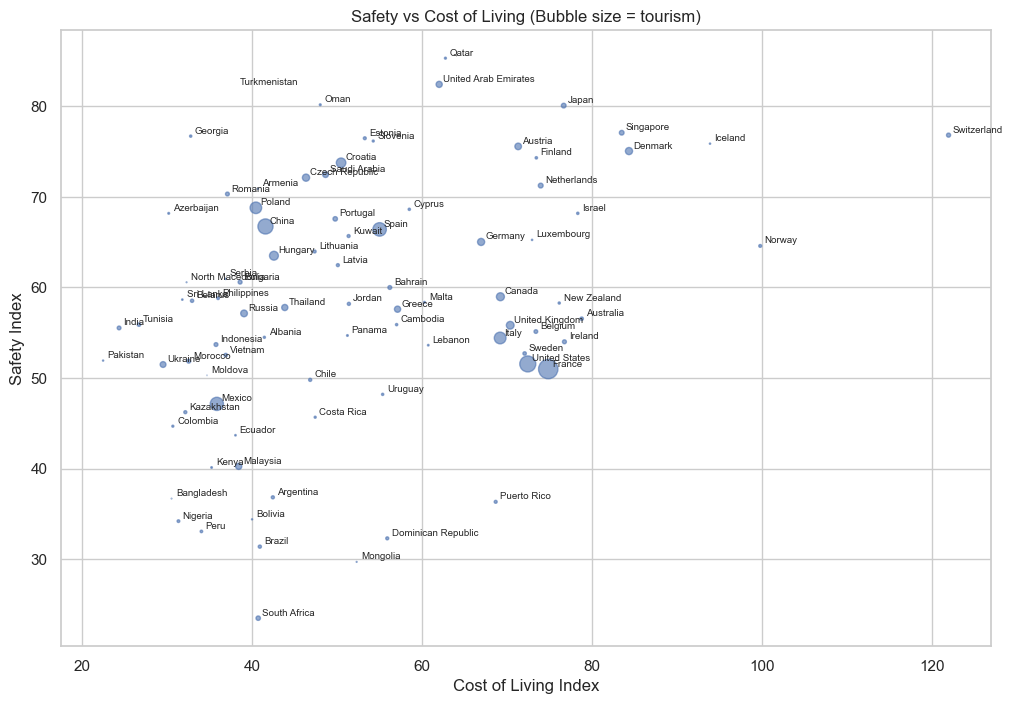

In [87]:
plt.figure(figsize=(12, 8))

plt.scatter(
    df_merged["cost_of_living_index"],
    df_merged["safety_index"],
    s=df_merged["tourism_arrivals"] / 1e6,  # scale
    alpha=0.6
)

for _, row in df_merged.iterrows():
    plt.text(
        row["cost_of_living_index"] + 0.5,
        row["safety_index"] + 0.3,
        row["country"],
        fontsize=7
    )

plt.xlabel("Cost of Living Index")
plt.ylabel("Safety Index")
plt.title("Safety vs Cost of Living (Bubble size = tourism)")
plt.show()

In [88]:
## Southeast Asia focus

In [89]:
sea_countries = ["Vietnam", "Thailand", "Indonesia", "Philippines", "Malaysia", "Cambodia", "Laos"]

df_sea = df_merged[df_merged["country"].isin(sea_countries)].copy()
df_sea

,country,safety_index,cost_of_living_index,tourism_arrivals
13,Cambodia,55.900000,57.000000,2.754545e+06
34,Indonesia,53.700000,35.760000,7.753318e+06
47,Malaysia,40.250000,38.430000,1.969623e+07
62,Philippines,58.815000,36.005000,3.767727e+06
78,Thailand,57.790000,43.850000,1.974562e+07
86,Vietnam,52.541176,36.905882,6.140455e+06


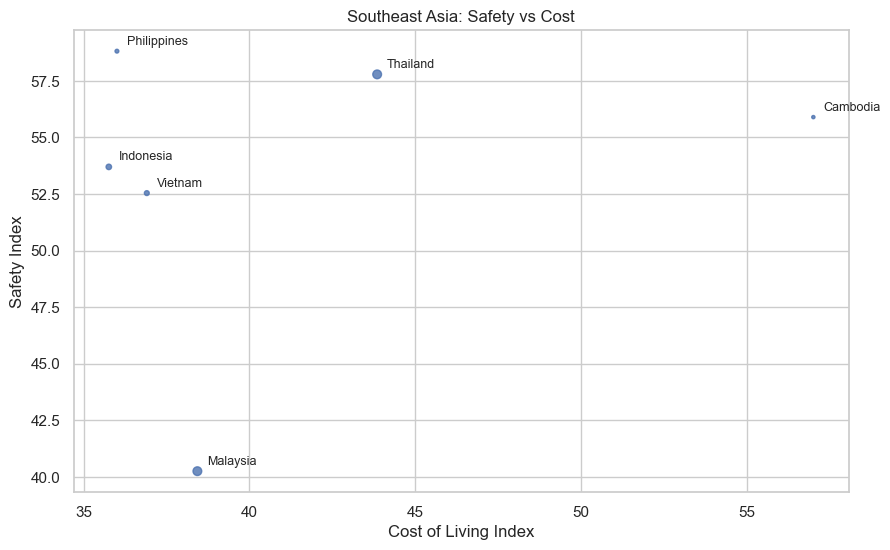

In [90]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df_sea["cost_of_living_index"],
    df_sea["safety_index"],
    s=df_sea["tourism_arrivals"] / 5e5,
    alpha=0.8
)

for _, row in df_sea.iterrows():
    plt.text(
        row["cost_of_living_index"] + 0.3,
        row["safety_index"] + 0.3,
        row["country"],
        fontsize=9
    )

plt.xlabel("Cost of Living Index")
plt.ylabel("Safety Index")
plt.title("Southeast Asia: Safety vs Cost")
plt.show()

In [91]:
## Top beginner-friendly destinations
###High safety, relatively lower cost, and strong tourism activity.

In [92]:
df_recommend = df_merged[
    (df_merged["safety_index"] >= 55) &
    (df_merged["cost_of_living_index"] < 60)
].copy()

In [93]:
df_recommend = df_recommend.sort_values(
    by=["safety_index", "tourism_arrivals"],
    ascending=[False, False]
)

In [94]:
df_recommend[["country", "safety_index", "cost_of_living_index", "tourism_arrivals"]].head(15)

,country,safety_index,cost_of_living_index,tourism_arrivals
80,Turkmenistan,82.100000,38.100000,NaN
58,Oman,80.180000,48.020000,1.859250e+06
28,Georgia,76.715385,32.784615,2.719045e+06
25,Estonia,76.482353,53.258824,4.525111e+06
72,Slovenia,76.173684,54.252632,2.212000e+06
19,Croatia,73.775000,50.470000,4.720300e+07
69,Saudi Arabia,72.460000,48.645000,1.673494e+07
21,Czech Republic,72.130000,46.345000,2.681282e+07
2,Armenia,70.900000,40.700000,7.157273e+05
67,Romania,70.325000,37.105000,7.636136e+06


In [95]:
## Distribution of safety and cost

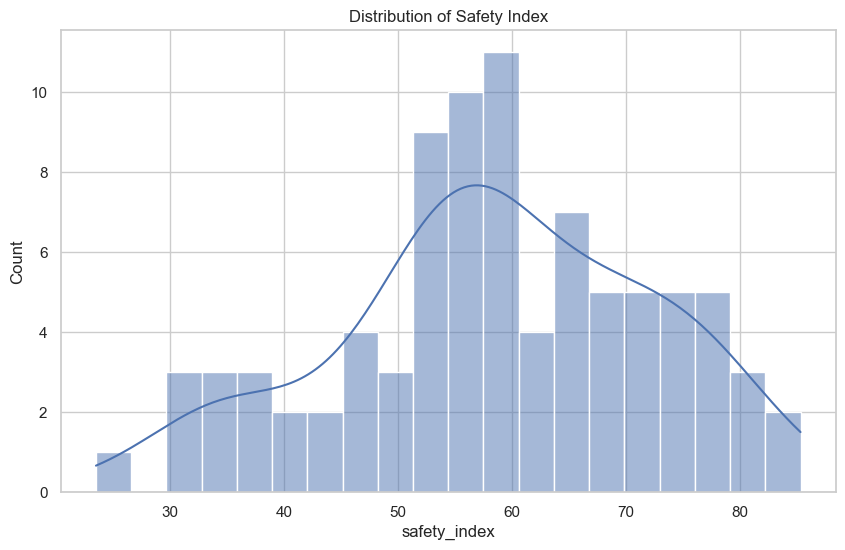

In [96]:
sns.histplot(df_merged["safety_index"], bins=20, kde=True)
plt.title("Distribution of Safety Index")
plt.show()

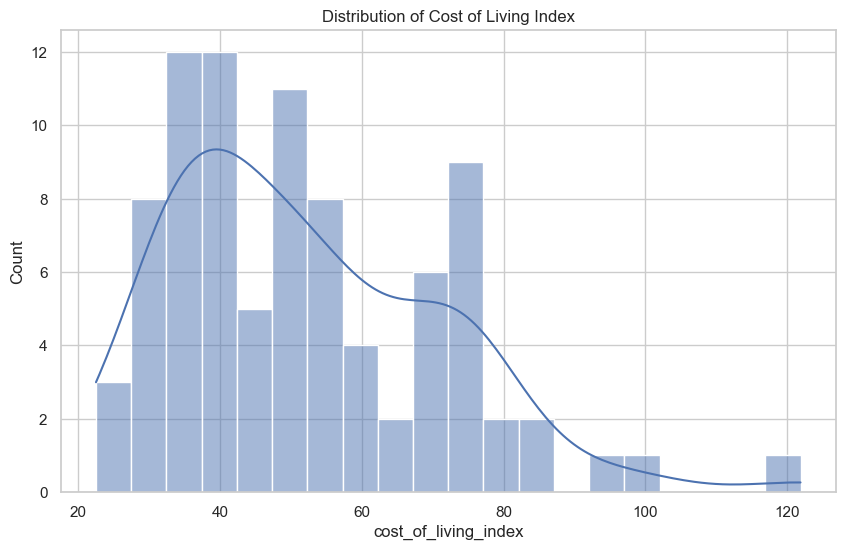

In [97]:
sns.histplot(df_merged["cost_of_living_index"], bins=20, kde=True)
plt.title("Distribution of Cost of Living Index")
plt.show()

In [98]:
## Correlation

In [99]:
df_merged[["safety_index", "cost_of_living_index", "tourism_arrivals"]].corr()

,safety_index,cost_of_living_index,tourism_arrivals
safety_index,1.000000,0.356726,0.042266
cost_of_living_index,0.356726,1.000000,0.133965
tourism_arrivals,0.042266,0.133965,1.000000


In [100]:
## Correlation heatmap
###Relationship between safety, cost, and tourism.

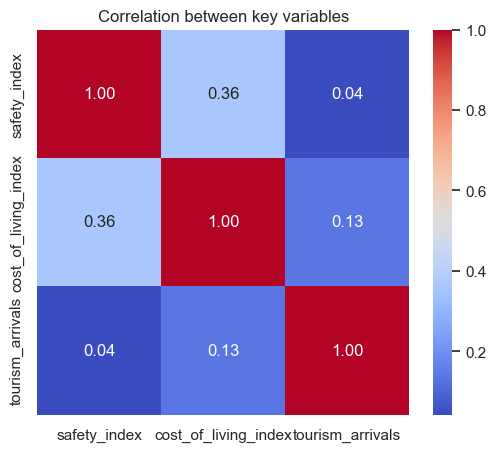

In [101]:
corr = df_merged[["safety_index", "cost_of_living_index", "tourism_arrivals"]].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Correlation between key variables")
plt.show()

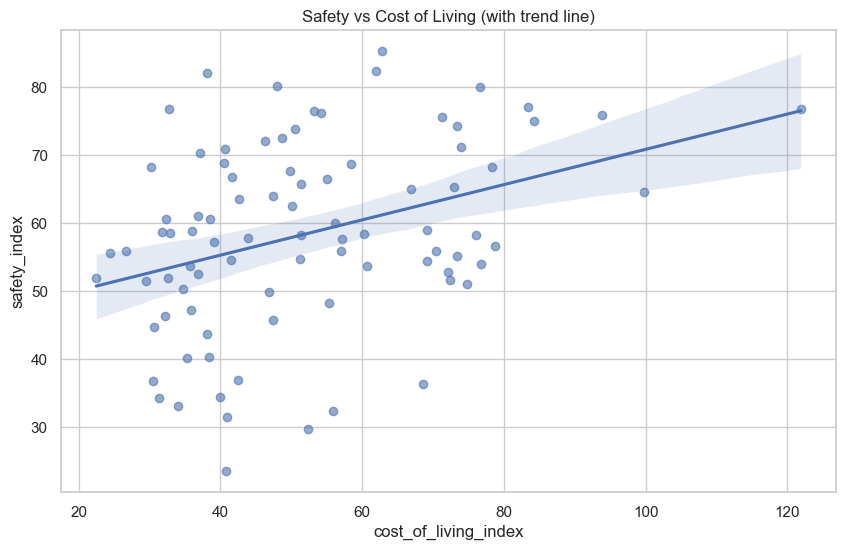

In [102]:
sns.regplot(
    data=df_merged,
    x="cost_of_living_index",
    y="safety_index",
    scatter_kws={"alpha": 0.6}
)

plt.title("Safety vs Cost of Living (with trend line)")
plt.show()

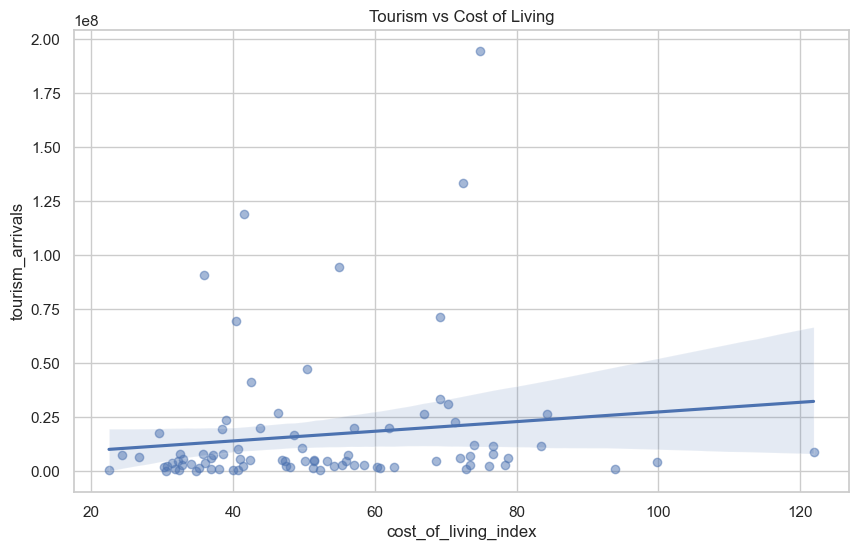

In [103]:
sns.regplot(
    data=df_merged,
    x="cost_of_living_index",
    y="tourism_arrivals",
    scatter_kws={"alpha": 0.5}
)

plt.title("Tourism vs Cost of Living")
plt.show()

In [104]:
## Key insights

###Countries with lower cost of living indices are not necessarily less safe.
###Southeast Asia stands out as a strong region for first-time solo travel due to its balance of affordability, tourism activity, and moderate safety.
###Tourism activity does not strongly correlate with cost or safety, suggesting that popularity is influenced by additional factors.
###The most approachable destinations are those that combine relatively lower cost, reasonable safety, and high tourism activity.